### Analysing PPG signals of red and IR LED for blood oxygen saturation extraction

This notebook presents a workflow of how to process PPG data from Red and IR LED to extract blood oygen saturtion

In [1]:
#Let's import some packages first
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.signal import normalize
import heartpy as hp

sample_rate = 10

c:\Users\kiril\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\heartpy\datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Firstly we need to separate IR and Red LED data

In [2]:
#load the example file
data = hp.get_data('m_red_IR.csv')
data_ir = []
data_red = []
data_ir = [item for index, item in enumerate(data) if index % 2 == 0]
data_red = [item for index, item in enumerate(data) if index % 2 != 0]


#### First let's take a look at the whole signal

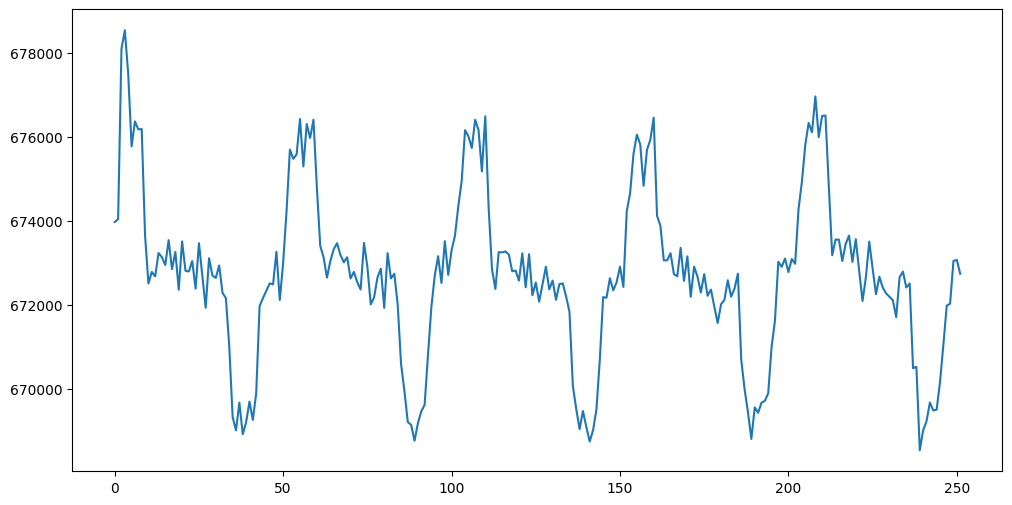

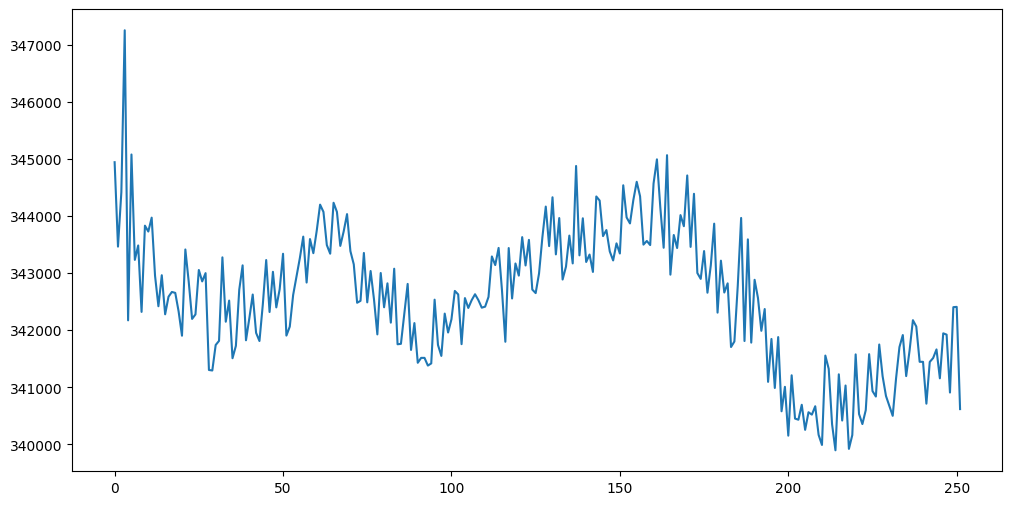

In [8]:
plt.figure(figsize=(12,6))
plt.plot(data_ir)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(data_red)
plt.show()

Data is quite noisy, so firstly it needs to be filttered

Also DC component of the data needed to be extracted

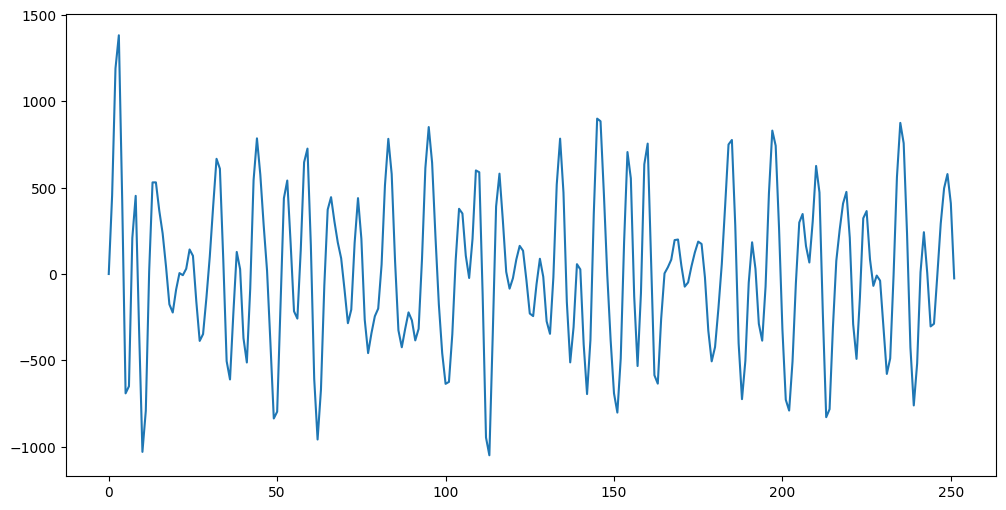

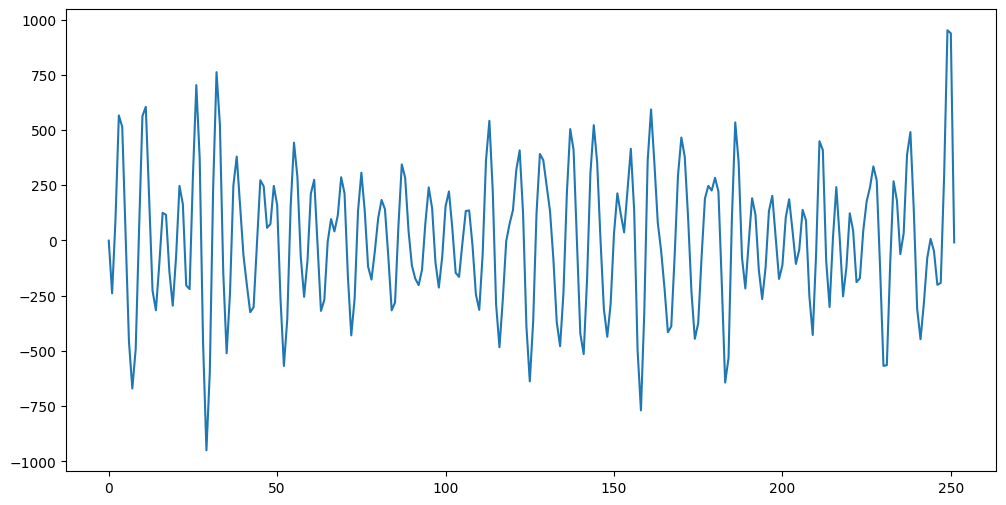

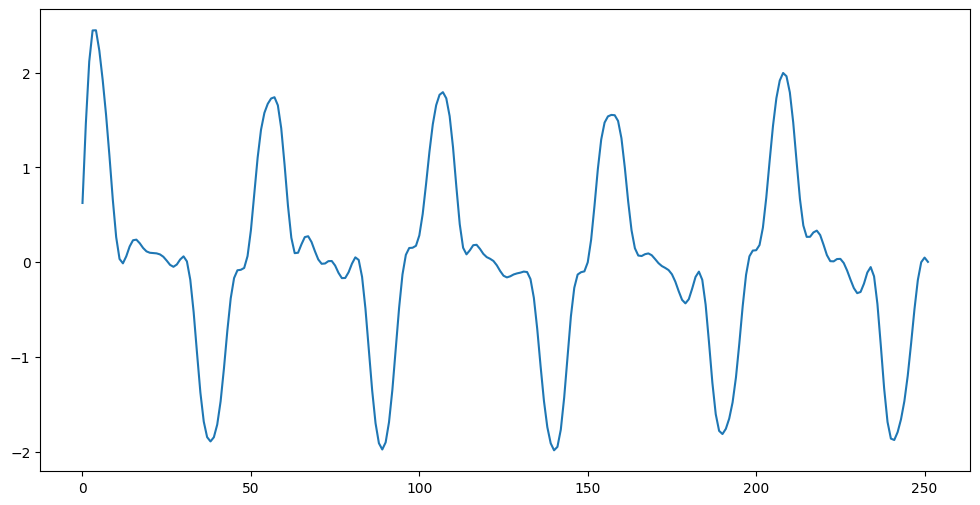

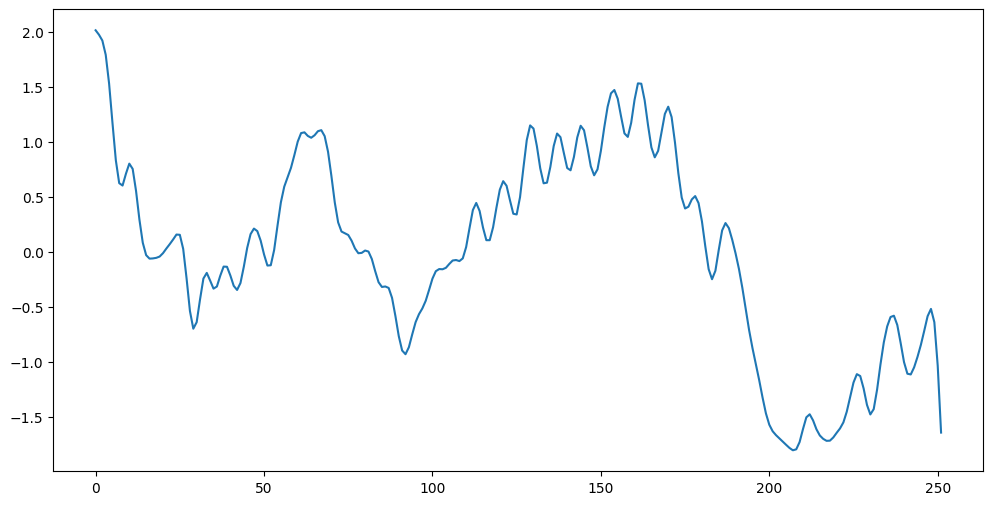

In [9]:
filtered_ppg_ir = hp.filter_signal(data_ir, 
                                cutoff = [0.8, 2.3], 
                                filtertype = 'bandpass',
                                sample_rate = sample_rate, 
                                order = 3,
                                return_top = False)

filtered_ppg_red = hp.filter_signal(data_red, 
                                cutoff = [0.8, 2.3], 
                                filtertype = 'bandpass',
                                sample_rate = sample_rate, 
                                order = 3,
                                return_top = False)

filtered_ppg_red_DC = hp.filter_signal(Z2[0:len(Z2)], cutoff=1.4, sample_rate=sample_rate, filtertype='lowpass',order=3, return_top=False)
filtered_ppg_ir_DC = hp.filter_signal(Z[0:len(Z)], cutoff=1.4, sample_rate=sample_rate, filtertype='lowpass',order=3, return_top=False)

#And let's plot the same segment as under 'zoomed in!' above
plt.figure(figsize=(12,6))
plt.plot(filtered_ppg_ir[0:len(filtered_ppg_ir)])
plt.show()

plt.figure(figsize=(12,6))
plt.plot(filtered_ppg_red[0:len(filtered_ppg_red)])
plt.show()

plt.figure(figsize=(12,6))
plt.plot(filtered_ppg_ir_DC[0:len(filtered_ppg_ir_DC)])
plt.show()

plt.figure(figsize=(12,6))
plt.plot(filtered_ppg_red_DC[0:len(filtered_ppg_red_DC)])
plt.show()

And after that we can calculate blood oxygen saturation

In [10]:
ratio_ir = np.mean(np.abs(filtered_ppg_ir[0:len(filtered_ppg_ir)])) / np.mean(np.abs(filtered_ppg_ir_DC[0:len(filtered_ppg_ir_DC)]))
ratio_red = np.mean(np.abs(filtered_ppg_red[0:len(filtered_ppg_red)])) / np.mean(np.abs(filtered_ppg_red_DC[0:len(filtered_ppg_red_DC)]))

spo2 = 110 - 25*(ratio_red/ratio_ir)

print("SpO2:", spo2, "%")

SpO2: 93.78807508241117 %
